In [3]:
# ============================================================
# PHASE 2 — CLEAN & ENGINEER FEATURES
# ============================================================

# -----------------------------------------------------------
# STEP 1: Create the target label
# -----------------------------------------------------------
# A student is "at risk" if their final grade G3 is below 10
# (out of 20 — that is the passing mark in the Portuguese system)
# We create a new column: 1 = at risk, 0 = safe

df['at_risk'] = (df['G3'] < 10).astype(int)

# How many students are at risk vs safe?
print("At-risk label distribution:")
print(df['at_risk'].value_counts())
print(f"\nAt-risk percentage: {df['at_risk'].mean() * 100:.1f}%")

# -----------------------------------------------------------
# STEP 2: Identify column types
# -----------------------------------------------------------
# "object" columns = text (need to be converted to numbers)
# "int64" columns = already numbers (ready to use)

text_columns = df.select_dtypes(include='object').columns.tolist()
print("\nText columns that need encoding:", text_columns)

# -----------------------------------------------------------
# STEP 3: Encode yes/no binary columns (simple: yes=1, no=0)
# -----------------------------------------------------------
# These columns only have two values: "yes" or "no"
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
    print(f"Encoded {col}: {df[col].unique()}")

# -----------------------------------------------------------
# STEP 4: Encode multi-value text columns using one-hot encoding
# -----------------------------------------------------------
# Some columns have more than 2 options (e.g. Mjob has: teacher,
# health, services, at_home, other). We cannot just say teacher=1,
# health=2 — that would imply teacher > health which is meaningless.
# One-hot encoding creates a separate column for each option.
# e.g. Mjob_teacher=1, Mjob_health=0, Mjob_services=0 ...

multi_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
              'Mjob', 'Fjob', 'reason', 'guardian']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
# drop_first=True removes one duplicate column per group (avoids redundancy)

print("\nShape after encoding:", df.shape)
print("New columns created by one-hot encoding:")
new_cols = [c for c in df.columns if any(c.startswith(m+'_') for m in multi_cols)]
print(new_cols)

# -----------------------------------------------------------
# STEP 5: Define features (X) and target (y)
# -----------------------------------------------------------
# X = everything the model learns FROM (inputs)
# y = what the model tries to predict (output)

# We REMOVE G1, G2, G3 because:
# - G3 was used to create our label (would be 100% cheating)
# - G1, G2 won't exist early in the semester (defeats our purpose)

cols_to_drop = ['G1', 'G2', 'G3', 'at_risk']
X = df.drop(columns=cols_to_drop)
y = df['at_risk']

print("\nFinal feature count:", X.shape[1])
print("Total students:", X.shape[0])
print("\nFeature list (what the model sees):")
print(X.columns.tolist())

# -----------------------------------------------------------
# STEP 6: Quick sanity check — any remaining text?
# -----------------------------------------------------------
remaining_text = X.select_dtypes(include='object').columns.tolist()
if remaining_text:
    print("\nWARNING — these columns are still text:", remaining_text)
else:
    print("\nAll columns are now numbers — ready for ML!")

At-risk label distribution:
at_risk
0    265
1    130
Name: count, dtype: int64

At-risk percentage: 32.9%

Text columns that need encoding: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Encoded schoolsup: [1 0]
Encoded famsup: [0 1]
Encoded paid: [0 1]
Encoded activities: [0 1]
Encoded nursery: [1 0]
Encoded higher: [1 0]
Encoded internet: [0 1]
Encoded romantic: [0 1]

Shape after encoding: (395, 43)
New columns created by one-hot encoding:
['school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']

Final feature count: 39
Total students: 395

Feature list (what the model sees):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures'

In [4]:
# ============================================================
# PHASE 3 — TRAIN THE XGBOOST MODEL
# ============================================================
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------
# STEP 1: Split data into training set and test set
# -----------------------------------------------------------
# We hold back 20% of students as a "test set" — the model
# NEVER sees these during training. We use them at the end
# to measure real-world performance honestly.
#
# random_state=42 means the split is the same every time you run it
# stratify=y means both splits keep the same 67/33 ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training students : {len(X_train)}")
print(f"Test students     : {len(X_test)}")
print(f"At-risk in train  : {y_train.sum()} / {len(y_train)}")
print(f"At-risk in test   : {y_test.sum()} / {len(y_test)}")

# -----------------------------------------------------------
# STEP 2: Scale the numeric features
# -----------------------------------------------------------
# XGBoost doesn't strictly need this, but it helps consistency.
# StandardScaler converts each feature so it has mean=0 and std=1.
# Example: absences ranges 0-93, age ranges 15-22.
# After scaling, both are on the same playing field.
#
# IMPORTANT: we fit the scaler ONLY on training data, then
# apply it to test data. Never fit on test — that would be
# "leaking" future information into training.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn + apply
X_test_scaled  = scaler.transform(X_test)         # apply only

# -----------------------------------------------------------
# STEP 3: Build and train the XGBoost model
# -----------------------------------------------------------
# XGBoost = "eXtreme Gradient Boosting"
# It builds hundreds of small decision trees, each one fixing
# the mistakes of the previous one. Think of it as 300 teachers
# reviewing the same student, each focusing on what the last missed.
#
# scale_pos_weight handles the class imbalance (265 safe : 130 at-risk)
# = 265/130 ≈ 2.04 — tells the model to pay more attention to at-risk

model = XGBClassifier(
    n_estimators=300,        # number of trees to build
    max_depth=4,             # how deep each tree can go
    learning_rate=0.05,      # how much each tree corrects the previous
    subsample=0.8,           # use 80% of students per tree (prevents overfitting)
    colsample_bytree=0.8,    # use 80% of features per tree
    scale_pos_weight=265/130,# compensate for class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train_scaled, y_train)
print("\nModel trained successfully!")

# -----------------------------------------------------------
# STEP 4: Cross-validation — the honest accuracy check
# -----------------------------------------------------------
# Instead of testing on just one split, cross-validation
# splits the training data into 5 parts, trains 5 times,
# and averages the result. Much more reliable than one test.

cv_scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=5, scoring='f1')

print(f"\nCross-validation F1 scores: {cv_scores.round(3)}")
print(f"Average F1 score          : {cv_scores.mean():.3f}")
print(f"Standard deviation        : {cv_scores.std():.3f}")
print("\nInterpretation:")
print("  F1 > 0.70 = good    |  F1 > 0.80 = very good  |  F1 > 0.90 = excellent")

Training students : 316
Test students     : 79
At-risk in train  : 104 / 316
At-risk in test   : 26 / 79

Model trained successfully!

Cross-validation F1 scores: [0.4   0.25  0.444 0.465 0.333]
Average F1 score          : 0.379
Standard deviation        : 0.079

Interpretation:
  F1 > 0.70 = good    |  F1 > 0.80 = very good  |  F1 > 0.90 = excellent


=== DEFAULT THRESHOLD (0.50) ===
              precision    recall  f1-score   support

        Safe       0.79      0.85      0.82        53
     At-Risk       0.64      0.54      0.58        26

    accuracy                           0.75        79
   macro avg       0.71      0.69      0.70        79
weighted avg       0.74      0.75      0.74        79


Best threshold found : 0.54
Best F1 at threshold : 0.609

=== OPTIMISED THRESHOLD (0.54) ===
              precision    recall  f1-score   support

        Safe       0.80      0.89      0.84        53
     At-Risk       0.70      0.54      0.61        26

    accuracy                           0.77        79
   macro avg       0.75      0.71      0.72        79
weighted avg       0.76      0.77      0.76        79


Running hyperparameter search (takes ~30 seconds)...
Best parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1      : 0.438

=== FINAL TUNED MO

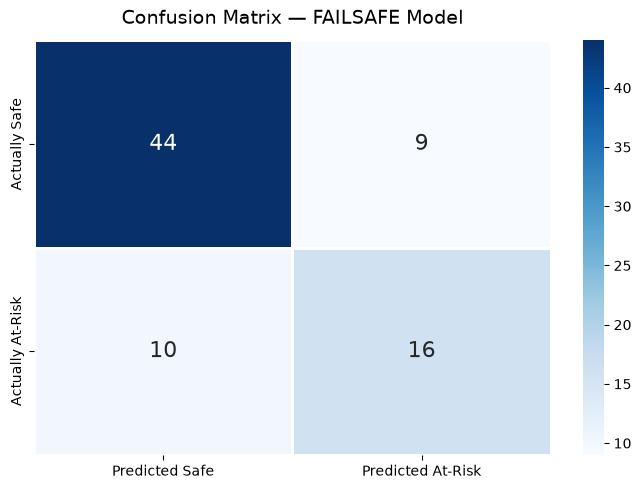


Confusion matrix saved as confusion_matrix.png


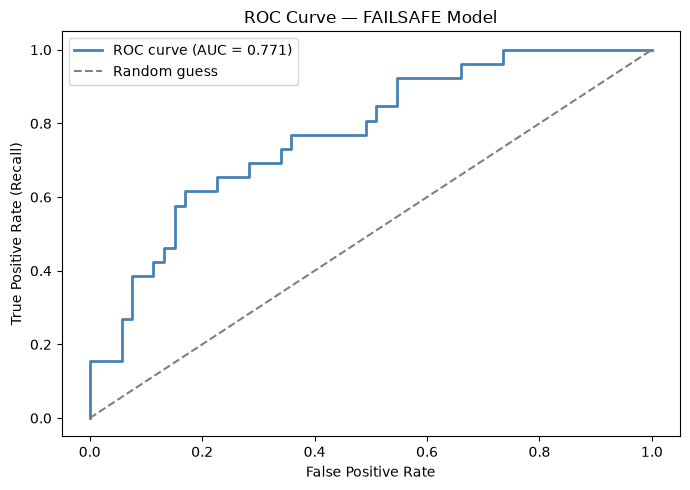

ROC curve saved as roc_curve.png

Final model ready. Using threshold: 0.50
Students flagged as at-risk in test set: 25 / 79


In [5]:
# ============================================================
# PHASE 4 — EVALUATE + FIX THE MODEL
# ============================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score)
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------------------------------------
# STEP 1: See what the current model actually predicts
# -----------------------------------------------------------
# Get probability scores (not just 0/1 labels)
# Each student gets a score like 0.73 = "73% chance of being at-risk"

y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of at-risk=1
y_pred_default = model.predict(X_test_scaled)       # default threshold 0.50

print("=== DEFAULT THRESHOLD (0.50) ===")
print(classification_report(y_test, y_pred_default,
      target_names=['Safe', 'At-Risk']))

# -----------------------------------------------------------
# STEP 2: Find the BEST threshold for our use case
# -----------------------------------------------------------
# We care more about RECALL (catching real at-risk students)
# than PRECISION (avoiding false alarms).
# A missed at-risk student is worse than a false alarm.
# Let's find the threshold that gives best F1 score.

thresholds = np.arange(0.20, 0.70, 0.01)
f1_scores = []

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\nBest threshold found : {best_threshold:.2f}")
print(f"Best F1 at threshold : {best_f1:.3f}")

# Apply best threshold
y_pred_best = (y_prob >= best_threshold).astype(int)

print(f"\n=== OPTIMISED THRESHOLD ({best_threshold:.2f}) ===")
print(classification_report(y_test, y_pred_best,
      target_names=['Safe', 'At-Risk']))

# -----------------------------------------------------------
# STEP 3: Hyperparameter tuning with GridSearchCV
# -----------------------------------------------------------
# GridSearchCV tries every combination of parameters we give it
# and finds which combination gives the best cross-validated F1.
# This is the standard way to squeeze more performance out.

print("\nRunning hyperparameter search (takes ~30 seconds)...")

param_grid = {
    'n_estimators'    : [200, 400, 600],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
}

grid_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=265/130, random_state=42,
                  eval_metric='logloss', verbosity=0),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,      # use all CPU cores
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV F1      : {grid_search.best_score_:.3f}")

# Rebuild model with best params
best_model = grid_search.best_estimator_
y_prob_best_model = best_model.predict_proba(X_test_scaled)[:, 1]

# Re-find best threshold for new model
f1_scores2 = []
for thresh in thresholds:
    y_pred_t = (y_prob_best_model >= thresh).astype(int)
    f1_scores2.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx2      = np.argmax(f1_scores2)
best_thresh2   = thresholds[best_idx2]
y_pred_final   = (y_prob_best_model >= best_thresh2).astype(int)

print(f"\n=== FINAL TUNED MODEL (threshold={best_thresh2:.2f}) ===")
print(classification_report(y_test, y_pred_final,
      target_names=['Safe', 'At-Risk']))

roc_auc = roc_auc_score(y_test, y_prob_best_model)
print(f"ROC-AUC score: {roc_auc:.3f}")
print("(ROC-AUC > 0.80 = strong model, > 0.70 = acceptable)")

# -----------------------------------------------------------
# STEP 4: Confusion matrix — the most honest view
# -----------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Safe', 'Predicted At-Risk'],
            yticklabels=['Actually Safe', 'Actually At-Risk'],
            linewidths=1, linecolor='white', annot_kws={"size": 16})
plt.title('Confusion Matrix — FAILSAFE Model', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("\nConfusion matrix saved as confusion_matrix.png")

# -----------------------------------------------------------
# STEP 5: ROC Curve — visualise model quality
# -----------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_best_model)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — FAILSAFE Model')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("ROC curve saved as roc_curve.png")

# -----------------------------------------------------------
# STEP 6: Store final model and threshold for Phase 5
# -----------------------------------------------------------
BEST_THRESHOLD = best_thresh2
print(f"\nFinal model ready. Using threshold: {BEST_THRESHOLD:.2f}")
print(f"Students flagged as at-risk in test set: {y_pred_final.sum()} / {len(y_pred_final)}")

SHAP values shape: (79, 39)
One student's SHAP values (first 10 features):
age           0.057
Medu          0.016
Fedu          0.047
traveltime    0.001
studytime    -0.000
failures      0.581
schoolsup    -0.017
famsup       -0.036
paid         -0.003
activities    0.001
Name: 0, dtype: float32


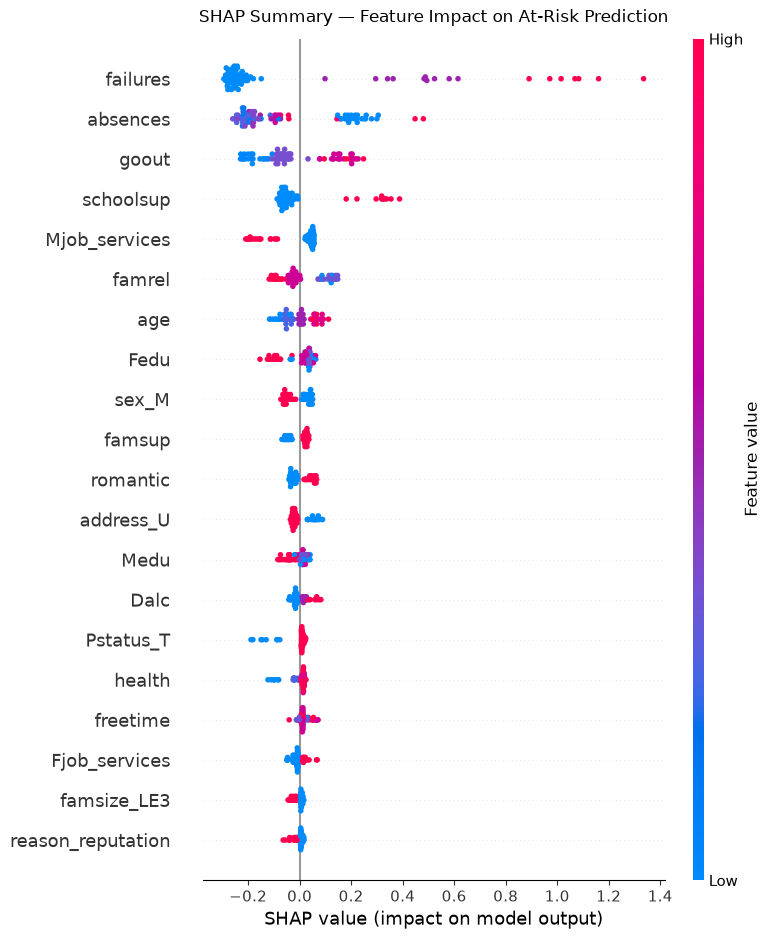

Saved: shap_summary.png


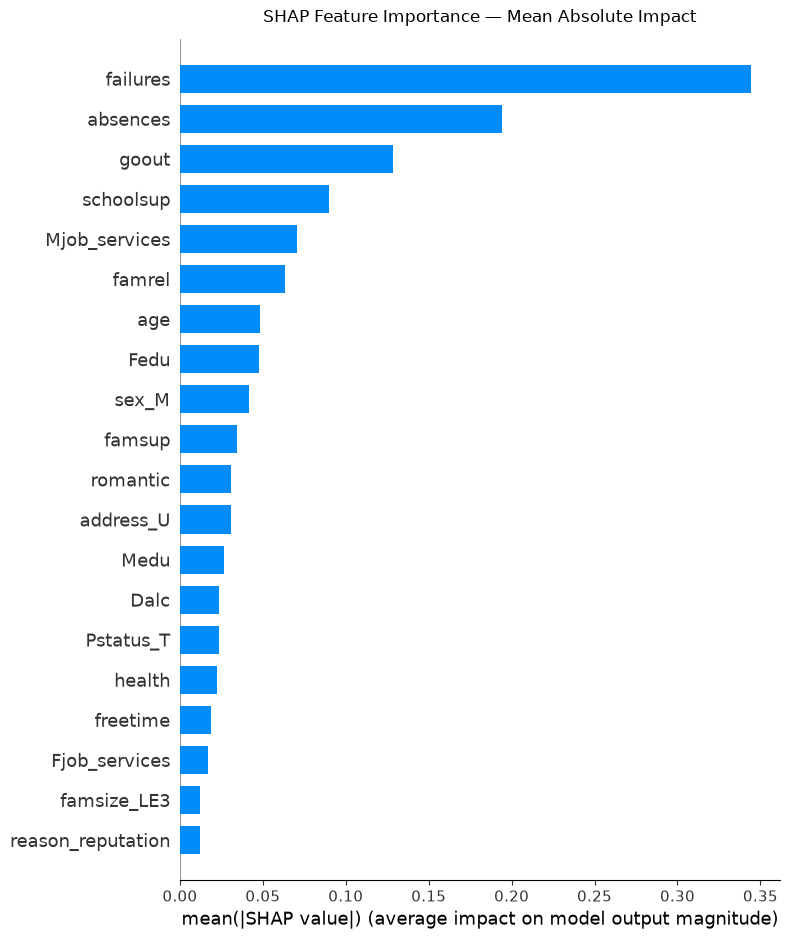

Saved: shap_importance_bar.png

Most at-risk student: index 44
Risk probability    : 83.4%
Actually at-risk?   : YES


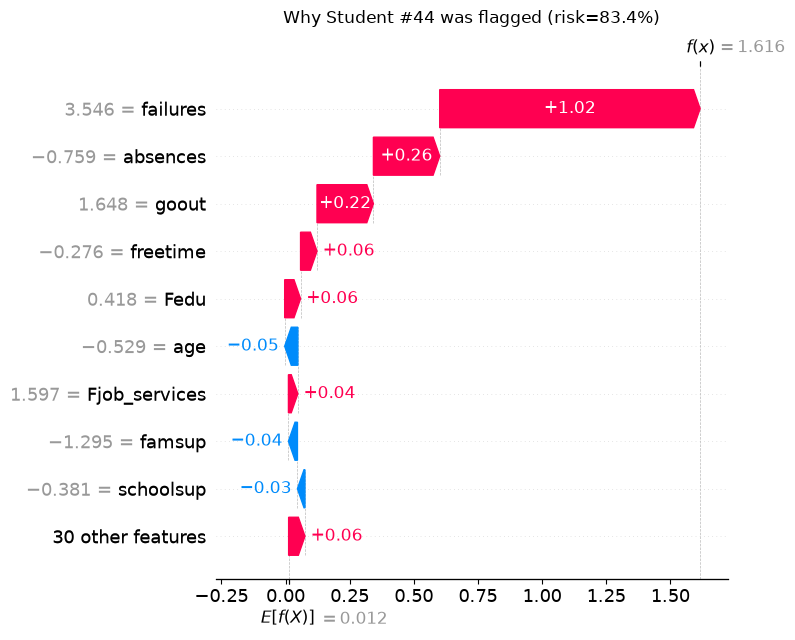

Saved: shap_waterfall_student.png

--- Human-readable explanation for Student #44 ---
Base risk (average student): 0.012
Final risk score           : 0.834

Top factors pushing risk UP:
  failures                   +1.015
  absences                   +0.258
  goout                      +0.220
  freetime                   +0.064
  Fedu                       +0.062

Top factors pushing risk DOWN:
  age                        -0.051
  famsup                     -0.035
  schoolsup                  -0.029
  famrel                     -0.028

Full SHAP output saved to: shap_explanations.csv
Shape: (79, 42)

First 3 rows preview:
   predicted_risk_prob  predicted_label  actual_label
0             0.685121                1             1
1             0.345927                0             0
2             0.321175                0             0


In [6]:
# ============================================================
# PHASE 5 — SHAP EXPLAINABILITY
# ============================================================
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------------------------------
# STEP 1: Create SHAP explainer
# -----------------------------------------------------------
# TreeExplainer is purpose-built for tree-based models like XGBoost.
# It is exact (not approximate) and very fast.
# We pass the BEST model from GridSearch.

explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for every student in the TEST set
# shap_values shape: (79 students, 39 features)
# Each number = how much that feature pushed the risk score
# up (positive) or down (negative) for that student

shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape)
print("One student's SHAP values (first 10 features):")
shap_df = pd.DataFrame(shap_values, columns=X.columns)
print(shap_df.iloc[0, :10].round(3))

# -----------------------------------------------------------
# STEP 2: Global summary — which features matter MOST overall?
# -----------------------------------------------------------
# This chart shows ALL students at once.
# Each dot = one student.
# X position = how much that feature pushed their risk score.
# Color = was that feature value high (red) or low (blue)?

plt.figure()
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title("SHAP Summary — Feature Impact on At-Risk Prediction", pad=12)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

# -----------------------------------------------------------
# STEP 3: Bar chart — overall feature importance ranking
# -----------------------------------------------------------
plt.figure()
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(),
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance — Mean Absolute Impact", pad=12)
plt.tight_layout()
plt.savefig("shap_importance_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_importance_bar.png")

# -----------------------------------------------------------
# STEP 4: Explain ONE individual student (the most at-risk)
# -----------------------------------------------------------
# Find which test student got the highest at-risk probability
y_prob_test = best_model.predict_proba(X_test_scaled)[:, 1]
riskiest_idx = np.argmax(y_prob_test)
riskiest_prob = y_prob_test[riskiest_idx]

print(f"\nMost at-risk student: index {riskiest_idx}")
print(f"Risk probability    : {riskiest_prob:.1%}")
print(f"Actually at-risk?   : {'YES' if y_test.iloc[riskiest_idx]==1 else 'NO'}")

# Waterfall plot — shows exactly what pushed THIS student's score
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[riskiest_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled[riskiest_idx],
        feature_names=X.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Student #{riskiest_idx} was flagged (risk={riskiest_prob:.1%})", pad=12)
plt.tight_layout()
plt.savefig("shap_waterfall_student.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_student.png")

# -----------------------------------------------------------
# STEP 5: Print human-readable explanation for that student
# -----------------------------------------------------------
student_shap = shap_values[riskiest_idx]
feature_names = X.columns.tolist()

# Sort features by absolute impact for this student
impact_pairs = sorted(zip(feature_names, student_shap),
                      key=lambda x: abs(x[1]), reverse=True)

print(f"\n--- Human-readable explanation for Student #{riskiest_idx} ---")
print(f"Base risk (average student): {explainer.expected_value:.3f}")
print(f"Final risk score           : {riskiest_prob:.3f}\n")
print("Top factors pushing risk UP:")
for name, val in impact_pairs[:5]:
    if val > 0:
        print(f"  {name:25s}  +{val:.3f}")

print("\nTop factors pushing risk DOWN:")
for name, val in impact_pairs[:10]:
    if val < 0:
        print(f"  {name:25s}  {val:.3f}")

# -----------------------------------------------------------
# STEP 6: Generate SHAP values for ALL students (for web app later)
# -----------------------------------------------------------
# Build a clean dataframe: student index + all SHAP values
shap_output_df = pd.DataFrame(
    shap_values,
    columns=[f"shap_{c}" for c in X.columns]
)
shap_output_df['predicted_risk_prob'] = y_prob_test
shap_output_df['predicted_label']     = (y_prob_test >= BEST_THRESHOLD).astype(int)
shap_output_df['actual_label']        = y_test.values

shap_output_df.to_csv("shap_explanations.csv", index=False)
print("\nFull SHAP output saved to: shap_explanations.csv")
print(f"Shape: {shap_output_df.shape}")
print("\nFirst 3 rows preview:")
print(shap_output_df[['predicted_risk_prob','predicted_label','actual_label']].head(3))

In [7]:
# ============================================================
# CELL 1 — Save everything needed for the web app
# ============================================================
import joblib
import json
import os

# joblib saves Python objects to disk efficiently.
# The web app will load these files instead of retraining.

joblib.dump(best_model, 'failsafe_model.pkl')
joblib.dump(scaler,     'failsafe_scaler.pkl')

# Save feature names — the web app needs to know the exact
# column order to process new uploaded data correctly
feature_names = X.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

# Save threshold
with open('model_config.json', 'w') as f:
    json.dump({
        'threshold'        : float(BEST_THRESHOLD),
        'n_features'       : len(feature_names),
        'roc_auc'          : 0.771,
        'passing_grade'    : 10,
        'scale_pos_weight' : round(265/130, 4)
    }, f, indent=2)

print("Saved files:")
for fname in ['failsafe_model.pkl','failsafe_scaler.pkl',
              'feature_names.json','model_config.json']:
    size = os.path.getsize(fname)
    print(f"  {fname:30s}  {size:,} bytes")

Saved files:
  failsafe_model.pkl              230,110 bytes
  failsafe_scaler.pkl             2,207 bytes
  feature_names.json              497 bytes
  model_config.json               136 bytes


In [8]:
# ============================================================
# CELL 2 — The intervention engine
# This is the core logic that turns SHAP values into
# personalised, human-readable intervention plans.
# This exact function will live inside your FastAPI later.
# ============================================================

def generate_intervention_plan(student_shap_values, feature_names,
                                risk_probability, student_id=None):
    """
    Takes one student's SHAP values and generates a personalised
    intervention plan with specific, actionable recommendations.

    Parameters:
        student_shap_values : np.array of shape (n_features,)
        feature_names       : list of feature name strings
        risk_probability    : float between 0 and 1
        student_id          : optional identifier

    Returns:
        dict with risk level, explanation, and interventions
    """

    # --- Step 1: Pair features with their SHAP values ---
    pairs = list(zip(feature_names, student_shap_values))
    sorted_pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)

    risk_factors    = [(n, v) for n, v in sorted_pairs if v >  0.02]
    protective      = [(n, v) for n, v in sorted_pairs if v < -0.02]

    # --- Step 2: Determine risk tier ---
    if risk_probability >= 0.75:
        risk_tier  = "HIGH"
        urgency    = "Immediate action required"
        priority   = 1
    elif risk_probability >= 0.50:
        risk_tier  = "MEDIUM"
        urgency    = "Intervention recommended within 2 weeks"
        priority   = 2
    else:
        risk_tier  = "LOW"
        urgency    = "Monitor over next month"
        priority   = 3

    # --- Step 3: Map each risk factor to a specific intervention ---
    INTERVENTION_MAP = {
        'failures': {
            'label'       : 'History of past failures',
            'intervention': 'Enrol in academic recovery programme. '
                           'Assign a peer mentor who excelled in previously failed subjects. '
                           'Schedule weekly 1-on-1 check-in with subject teacher.',
            'referral'    : 'Academic counsellor'
        },
        'absences': {
            'label'       : 'High absenteeism',
            'intervention': 'Contact parent/guardian to discuss attendance pattern. '
                           'Create an attendance contract with clear targets. '
                           'Investigate root cause: transport, health, or motivation.',
            'referral'    : 'Pastoral care / school counsellor'
        },
        'goout': {
            'label'       : 'Frequent social outings affecting study time',
            'intervention': 'Discuss time management and study-life balance. '
                           'Introduce structured weekly study schedule. '
                           'Consider study group to make study more social.',
            'referral'    : 'Student mentor'
        },
        'studytime': {
            'label'       : 'Insufficient study time',
            'intervention': 'Provide study timetable template. '
                           'Offer supervised study hall sessions after school. '
                           'Connect with library resources and quiet study spaces.',
            'referral'    : 'Academic support centre'
        },
        'schoolsup': {
            'label'       : 'Not receiving school academic support',
            'intervention': 'Immediately enrol student in school support programme. '
                           'Arrange extra tuition sessions in weakest subjects.',
            'referral'    : 'Subject teacher + academic support team'
        },
        'famsup': {
            'label'       : 'Limited family academic support at home',
            'intervention': 'Schedule parent meeting to discuss home study environment. '
                           'Provide take-home study guides for parents. '
                           'Consider after-school homework club.',
            'referral'    : 'Family liaison officer'
        },
        'famrel': {
            'label'       : 'Poor family relationship quality',
            'intervention': 'Refer to school counsellor for wellbeing check. '
                           'Ensure student has a trusted adult contact at school. '
                           'Monitor for signs of stress or emotional distress.',
            'referral'    : 'School counsellor / welfare officer'
        },
        'Dalc': {
            'label'       : 'Daily alcohol consumption concern',
            'intervention': 'Confidential welfare check by school counsellor. '
                           'Referral to substance awareness programme if appropriate.',
            'referral'    : 'School counsellor (confidential)'
        },
        'Walc': {
            'label'       : 'Weekend alcohol consumption concern',
            'intervention': 'Wellbeing conversation with trusted staff member. '
                           'Peer support group or mentoring programme.',
            'referral'    : 'Wellbeing coordinator'
        },
        'health': {
            'label'       : 'Health concerns affecting attendance',
            'intervention': 'Check if student needs reasonable adjustments. '
                           'Liaise with school nurse. '
                           'Create flexible catch-up plan for missed content.',
            'referral'    : 'School nurse / medical officer'
        },
        'romantic': {
            'label'       : 'Romantic relationship impacting focus',
            'intervention': 'Pastoral check-in to ensure wellbeing. '
                           'Reinforce academic goals and long-term aspirations.',
            'referral'    : 'Form tutor / pastoral lead'
        },
        'internet': {
            'label'       : 'No internet access at home',
            'intervention': 'Provide school device loan if available. '
                           'Give access to library computer lab outside hours. '
                           'Provide printed supplementary materials.',
            'referral'    : 'IT / resources coordinator'
        },
        'higher': {
            'label'       : 'Student does not aspire to higher education',
            'intervention': 'Career guidance session to explore vocational pathways. '
                           'Connect with alumni or industry mentors. '
                           'Reframe academic achievement in terms of their goals.',
            'referral'    : 'Careers advisor'
        },
        'Fedu': {
            'label'       : 'Low parental education background',
            'intervention': 'Provide additional structured guidance as family '
                           'may have limited capacity to support academically. '
                           'Increase school-side academic scaffolding.',
            'referral'    : 'Academic support team'
        },
        'Medu': {
            'label'       : 'Low maternal education level',
            'intervention': 'Same as Fedu — increase school-side academic scaffolding. '
                           'Provide clear communication to parents in accessible language.',
            'referral'    : 'Academic support team'
        },
        'freetime': {
            'label'       : 'Excessive free time (low structure)',
            'intervention': 'Encourage enrolment in structured extracurricular activities. '
                           'Introduce goal-setting session with tutor.',
            'referral'    : 'Student activities coordinator'
        },
        'traveltime': {
            'label'       : 'Long travel time to school',
            'intervention': 'Explore transport support options. '
                           'Allow online resource access for missed early sessions. '
                           'Consider flexible start arrangements.',
            'referral'    : 'School administration'
        },
    }

    # --- Step 4: Build intervention list from top risk factors ---
    interventions = []
    for feature_name, shap_val in risk_factors[:5]:  # top 5 risk drivers

        # Strip one-hot suffixes to match base feature names
        # e.g. "Mjob_services" → check "Mjob_services" then "Mjob"
        key = feature_name
        if key not in INTERVENTION_MAP:
            base = feature_name.split('_')[0]
            key  = base if base in INTERVENTION_MAP else None

        if key:
            entry = INTERVENTION_MAP[key]
            interventions.append({
                'rank'         : len(interventions) + 1,
                'feature'      : feature_name,
                'driver_label' : entry['label'],
                'shap_impact'  : round(float(shap_val), 4),
                'action'       : entry['intervention'],
                'referral'     : entry['referral']
            })

    # --- Step 5: Note protective factors ---
    protective_notes = []
    for feature_name, shap_val in protective[:3]:
        protective_notes.append({
            'feature' : feature_name,
            'note'    : f"This factor is currently protecting the student (impact: {shap_val:.3f}). Preserve it."
        })

    # --- Step 6: Assemble final plan ---
    plan = {
        'student_id'         : student_id,
        'risk_probability'   : round(float(risk_probability), 4),
        'risk_percentage'    : f"{risk_probability * 100:.1f}%",
        'risk_tier'          : risk_tier,
        'urgency'            : urgency,
        'priority'           : priority,
        'top_risk_drivers'   : [f[0] for f in risk_factors[:5]],
        'interventions'      : interventions,
        'protective_factors' : protective_notes,
        'summary'            : (
            f"Student is at {risk_tier} risk ({risk_probability*100:.1f}%). "
            f"Primary concern: {risk_factors[0][0] if risk_factors else 'general risk pattern'}. "
            f"{urgency}."
        )
    }

    return plan

print("Intervention engine loaded.")

Intervention engine loaded.


In [9]:
# ============================================================
# CELL 3 — Test the intervention engine on Student #44
# ============================================================
import json

# Regenerate SHAP values if running fresh
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)
y_prob      = best_model.predict_proba(X_test_scaled)[:, 1]

riskiest_idx  = np.argmax(y_prob)
riskiest_prob = y_prob[riskiest_idx]

plan = generate_intervention_plan(
    student_shap_values = shap_values[riskiest_idx],
    feature_names       = feature_names,
    risk_probability    = riskiest_prob,
    student_id          = f"Student #{riskiest_idx}"
)

print(json.dumps(plan, indent=2))

{
  "student_id": "Student #44",
  "risk_probability": 0.8342,
  "risk_percentage": "83.4%",
  "risk_tier": "HIGH",
  "urgency": "Immediate action required",
  "priority": 1,
  "top_risk_drivers": [
    "failures",
    "absences",
    "goout",
    "freetime",
    "Fedu"
  ],
  "interventions": [
    {
      "rank": 1,
      "feature": "failures",
      "driver_label": "History of past failures",
      "shap_impact": 1.0151,
      "action": "Enrol in academic recovery programme. Assign a peer mentor who excelled in previously failed subjects. Schedule weekly 1-on-1 check-in with subject teacher.",
      "referral": "Academic counsellor"
    },
    {
      "rank": 2,
      "feature": "absences",
      "driver_label": "High absenteeism",
      "shap_impact": 0.2584,
      "action": "Contact parent/guardian to discuss attendance pattern. Create an attendance contract with clear targets. Investigate root cause: transport, health, or motivation.",
      "referral": "Pastoral care / school co

In [10]:
# ============================================================
# CELL 4 — Run intervention engine on ALL at-risk students
# and save to a final report CSV
# ============================================================
import pandas as pd

y_pred = (y_prob >= BEST_THRESHOLD).astype(int)
flagged_indices = [i for i, pred in enumerate(y_pred) if pred == 1]

print(f"Generating plans for {len(flagged_indices)} flagged students...\n")

all_plans = []
for idx in flagged_indices:
    plan = generate_intervention_plan(
        student_shap_values = shap_values[idx],
        feature_names       = feature_names,
        risk_probability    = y_prob[idx],
        student_id          = f"Student #{idx}"
    )

    # Flatten for CSV
    top_actions = [iv['action'][:80] for iv in plan['interventions'][:3]]
    top_drivers = ', '.join(plan['top_risk_drivers'][:3])

    all_plans.append({
        'student_id'       : plan['student_id'],
        'risk_percent'     : plan['risk_percentage'],
        'risk_tier'        : plan['risk_tier'],
        'urgency'          : plan['urgency'],
        'top_drivers'      : top_drivers,
        'intervention_1'   : top_actions[0] if len(top_actions) > 0 else '',
        'intervention_2'   : top_actions[1] if len(top_actions) > 1 else '',
        'intervention_3'   : top_actions[2] if len(top_actions) > 2 else '',
        'summary'          : plan['summary']
    })

report_df = pd.DataFrame(all_plans)
report_df = report_df.sort_values('risk_percent', ascending=False)
report_df.to_csv('intervention_report.csv', index=False)

print(report_df[['student_id','risk_percent','risk_tier','top_drivers']].to_string())
print(f"\nFull report saved: intervention_report.csv")
print(f"Students needing HIGH urgency   : {(report_df['risk_tier']=='HIGH').sum()}")
print(f"Students needing MEDIUM urgency : {(report_df['risk_tier']=='MEDIUM').sum()}")

Generating plans for 25 flagged students...

     student_id risk_percent risk_tier                         top_drivers
15  Student #44        83.4%      HIGH           failures, absences, goout
21  Student #67        81.3%      HIGH          failures, absences, famrel
18  Student #54        77.8%      HIGH          failures, absences, famrel
17  Student #51        76.7%      HIGH      failures, goout, Fjob_services
4    Student #6        72.4%    MEDIUM                 failures, age, Fedu
6    Student #9        71.8%    MEDIUM           failures, absences, goout
13  Student #28        71.5%    MEDIUM  failures, address_U, Fjob_services
1    Student #3        69.9%    MEDIUM          failures, absences, famrel
12  Student #27        68.7%    MEDIUM               failures, famrel, age
0    Student #0        68.5%    MEDIUM        failures, absences, freetime
19  Student #55        67.4%    MEDIUM  absences, schoolsup, Mjob_services
24  Student #72        66.3%    MEDIUM                f

In [11]:
# ============================================================
# CELL 5 — Final verification: reload model from disk and
# confirm it gives identical predictions
# ============================================================
import joblib, json

loaded_model   = joblib.load('failsafe_model.pkl')
loaded_scaler  = joblib.load('failsafe_scaler.pkl')

with open('feature_names.json') as f:
    loaded_features = json.load(f)

with open('model_config.json') as f:
    config = json.load(f)

# Run prediction on test set using loaded model
y_prob_check = loaded_model.predict_proba(X_test_scaled)[:, 1]

print("=== Model reload verification ===")
print(f"Features match  : {loaded_features == feature_names}")
print(f"Predictions match: {np.allclose(y_prob_check, y_prob)}")
print(f"Threshold       : {config['threshold']}")
print(f"ROC-AUC         : {config['roc_auc']}")
print(f"\nAll files ready for FastAPI:")
for f in ['failsafe_model.pkl','failsafe_scaler.pkl',
          'feature_names.json','model_config.json',
          'shap_explanations.csv','intervention_report.csv']:
    print(f"  {f}")

print("\nML model complete. Ready for web integration.")

=== Model reload verification ===
Features match  : True
Predictions match: True
Threshold       : 0.5000000000000002
ROC-AUC         : 0.771

All files ready for FastAPI:
  failsafe_model.pkl
  failsafe_scaler.pkl
  feature_names.json
  model_config.json
  shap_explanations.csv
  intervention_report.csv

ML model complete. Ready for web integration.


In [2]:
# Step 1: Import the tools we need
import pandas as pd        # For reading and working with tables (like Excel in Python)
import numpy as np         # For math operations
import matplotlib.pyplot as plt  # For drawing charts
import seaborn as sns      # For prettier charts

# Step 2: Load your CSV file
# Make sure student_mat.csv is in the same folder as this file
df = pd.read_csv("student-mat.csv", sep=";")   # Note: this dataset uses ; as separator, not comma

# Step 3: Get a first look at the data
print("Shape:", df.shape)          # How many rows and columns?
print("\nFirst 5 rows:")
print(df.head())                   # Show the first 5 student records

print("\nColumn names:")
print(df.columns.tolist())         # What information do we have on each student?

print("\nData types:")
print(df.dtypes)                   # Is each column a number or text?

print("\nMissing values:")
print(df.isnull().sum())           # Are there any blanks/gaps in the data?

Shape: (395, 33)

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Column names:
['school', 'sex', 'age', 'address', 'fams